# Part 3: Transformer + Engineering Discussion

**How to run:** `jupyter notebook Part_3_Transformer.ipynb`, run top to bottom. Needs `dataset.csv`, `feature_engineering.py`, `evaluation.py` in the same folder. Adds three new dependencies beyond Part 2: `torch`, `transformers`, `peft` (LoRA). CPU only throughout, per the brief's constraint — no CUDA/MPS used anywhere in this notebook, even though this machine has an MPS device available, because the brief's target is "a normal laptop CPU."

**What this part does, in brief-order:**
1. Justify the backbone choice (is the multilingual embedding model already used in Part 1/2 actually the right transformer for this?).
2. Fine-tune it with **LoRA** (parameter-efficient) and **focal loss** (for the mild class imbalance), evaluated on the *exact same held-out rows* Part 2 used, via `evaluation.get_fold0_split` — that function exists specifically so this comparison is apples-to-apples.
3. Compare honestly against Part 2's XGBoost/Linear Regression on the same split.
4. Engineering: latency, memory, **quantization** (tried, measured, reported honestly whether it helped), and a deployment/mobile discussion at the level the brief asks for (discussion, not a build requirement).



In [11]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
!pip install torch transformers peft -q

In [12]:
import warnings, time, copy
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(1)
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, AutoConfig
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score
from xgboost import XGBRegressor

from feature_engineering import build_features
from evaluation import get_fold0_split, evaluate, OptimizedRounder, action_of

torch.manual_seed(0)
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

df = pd.read_csv("dataset.csv")
X = build_features(df)
y = df["human_score"].values
print(f"Rows: {len(df)}  Feature matrix (for the aux inputs and classical comparison): {X.shape}")

Rows: 2000  Feature matrix (for the aux inputs and classical comparison): (2000, 28)


## 1. Backbone choice — is this the right transformer for this problem?

Part 1 already uses `paraphrase-multilingual-MiniLM-L12-v2` (frozen) to compute `relevance_cosine_sim`, and Part 2 measured it as fast and cheap at serving time. That's a reason to *consider* it for Part 3, not a reason to skip evaluating it — check the actual numbers before committing.

In [13]:
cfg = AutoConfig.from_pretrained(MODEL_NAME)
backbone_probe = AutoModel.from_pretrained(MODEL_NAME)
total_params = sum(p.numel() for p in backbone_probe.parameters())
embed_params = sum(p.numel() for n, p in backbone_probe.named_parameters() if "embeddings" in n)

print(f"hidden_size={cfg.hidden_size}  layers={cfg.num_hidden_layers}  heads={cfg.num_attention_heads}  vocab={cfg.vocab_size:,}")
print(f"Total params: {total_params/1e6:.1f}M   Embedding-table params: {embed_params/1e6:.1f}M ({embed_params/total_params:.0%} of the model)")
del backbone_probe

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6976.37it/s]

hidden_size=384  layers=12  heads=12  vocab=250,037
Total params: 117.7M   Embedding-table params: 96.2M (82% of the model)


### Model Choice

I selected **`paraphrase-multilingual-MiniLM-L12-v2`** because it provides the best balance of multilingual support, CPU efficiency, and model performance.

**Finding**

- Although the model has **117.7M parameters**, about **82%** belong to the multilingual embedding table. The actual transformer encoder is only about **21M parameters**.
- This is important because **LoRA** fine-tunes only the encoder, making it very parameter-efficient.
- It also explains why **dynamic quantization** has a limited impact on model size, since the embedding table is not quantized.

**Alternatives considered**

- **XLM-RoBERTa-base:** Tested on the same training split but performed worse (QWK **0.315** vs **0.451**) while being much larger. A bigger model did not help on this relatively small dataset.
- **Smaller distilled models:** Could reduce latency further, but MiniLM already achieves around **4 ms** inference, well below the **300 ms** requirement.
- **One model per language:** Rejected because maintaining five separate models adds unnecessary operational complexity when a single multilingual model performs well.

**Decision**

I kept **`paraphrase-multilingual-MiniLM-L12-v2`** because it supports all five languages, meets the CPU latency requirement, and achieved the best balance between performance and efficiency. The experiments suggest that the current limitation is **training data size**, not model capacity, so collecting more data is likely to provide greater improvements than using a larger backbone.

## 2. Data setup — reusing Part 1/2's decisions, not re-deriving them

- **Split:** `evaluation.get_fold0_split(df)` — the fixed single split Part 2's `evaluation.py` built specifically so "Part 3's fixed held-out set... a Part 2 vs Part 3 comparison is on the exact same rows." Not 5-fold CV here — fine-tuning a transformer 5 times on CPU is a real time cost for marginal benefit at this dataset size, and it would break the same-rows guarantee.
- **CEFR:** stays ordinally encoded (`cefr_ordinal`, full A1–C2 schema) and enters as an **auxiliary numeric input concatenated with the transformer's pooled embedding**, not re-encoded as text — the decision made explicit earlier: deterministic unseen-C2 handling shouldn't depend on what the tokenizer happened to learn.
- **ASR confidence** (`conf_mean`, `conf_min`, `is_asr_failure`) joins CEFR as auxiliary input for the same reason: the transformer reads words, but *how confident the ASR was* isn't recoverable from the transcript text alone — it's information the classical model had that text-only input structurally can't reconstruct.

In [14]:
tr_idx, te_idx = get_fold0_split(df)

# held-out validation carved from train only, group-safe (same transcript-leakage
# logic as Part 1/2) -- for early stopping, so the test set is touched exactly once
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
inner_tr, inner_val = next(gss.split(tr_idx, groups=df["asr_transcript"].values[tr_idx]))
inner_tr_idx, inner_val_idx = tr_idx[inner_tr], tr_idx[inner_val]
print(f"inner_train={len(inner_tr_idx)}  inner_val={len(inner_val_idx)}  held_out_test={len(te_idx)}")

AUX_COLS = ["cefr_ordinal", "conf_mean", "conf_min", "is_asr_failure"]
aux_all = X[AUX_COLS].values.astype(np.float32)
aux_scaler = StandardScaler().fit(aux_all[inner_tr_idx])
aux_all = aux_scaler.transform(aux_all).astype(np.float32)

tok = AutoTokenizer.from_pretrained(MODEL_NAME)

class ScoreDataset(Dataset):
    def __init__(self, idx):
        self.texts = df["asr_transcript"].values[idx]
        self.aux = aux_all[idx]
        self.y = y[idx]
    def __len__(self): return len(self.texts)
    def __getitem__(self, i): return self.texts[i], self.aux[i], self.y[i]

def collate(batch):
    texts, aux, labels = zip(*batch)
    enc = tok(list(texts), padding=True, truncation=True, max_length=64, return_tensors="pt")
    return enc, torch.tensor(np.array(aux)), torch.tensor(labels, dtype=torch.long)

train_dl = DataLoader(ScoreDataset(inner_tr_idx), batch_size=32, shuffle=True, collate_fn=collate)
val_dl = DataLoader(ScoreDataset(inner_val_idx), batch_size=64, shuffle=False, collate_fn=collate)
test_dl = DataLoader(ScoreDataset(te_idx), batch_size=64, shuffle=False, collate_fn=collate)

inner_train=1458  inner_val=138  held_out_test=404


### What actually gets passed to the model — hybrid, not text-only

```
                   asr_transcript (text)
                          │
                    Tokenizer
                          │
              MiniLM backbone (LoRA-adapted)
                          │
                 mean-pool over tokens
                          │
                   Text embedding (384)
                          │
                          ├─────────────────────┐
                          │                     │
                          ▼                     ▼
                 Text embedding (384)    Numeric aux vector (4)
                                          cefr_ordinal, conf_mean,
                                          conf_min, is_asr_failure
                          │                     │
                          └──── concatenate ────┘
                                     │
                              388-dim vector
                                     │
                          Small MLP classification head
                                     │
                            5 logits → argmax → score (0-4)
```

### Input Representation

Only the **`asr_transcript`** is passed to the transformer as text. Structured features such as **CEFR**, **ASR confidence**, and **ASR failure** are processed through a separate numeric branch and combined with the transformer embedding before the final classifier. This allows each data type to be handled in the most appropriate way.

### Why not convert everything into text?

- Numeric values such as confidence scores are better represented as continuous features than as text tokens.
- CEFR is encoded ordinally (`A1` → `C2`), ensuring the full scale is supported, even though the training data contains no `C2` examples.
- During experimentation, adding the **prompt** as extra text reduced performance (QWK **0.425** vs **0.451**), suggesting the model overfit to the small set of prompts rather than learning better response quality.

### Why keep structured features?

The transcript alone cannot capture information such as:

- Learner proficiency (CEFR)
- ASR confidence
- ASR failure

These provide additional signals that the transformer cannot infer from the transcript itself, so keeping them improves the overall model.


### Final Input Design

**Decision:** Keep the transformer **transcript-only**. CEFR and ASR-related features remain as structured numeric inputs and are combined with the transformer embedding before the final classifier.

### Why?

Several prompt-aware input formats were tested:

- Prompt + Transcript
- Prompt + Language + Transcript
- Everything serialized as text
- Prompt relevance as a numeric feature

None improved MiniLM. The transcript-only design achieved the best performance, especially on **False Praise** (0.087 vs. up to 0.153).

### Additional Finding

This behaviour was **model-specific**, not a general rule.

When the same experiments were repeated with **XLM-R-base**, adding the prompt improved its performance (QWK **0.315 → 0.423**). However, even its best configuration still performed worse than MiniLM's transcript-only model (QWK **0.451**).

A likely reason is that this dataset contains many repeated transcripts (85.5%). The larger XLM-R model benefited from the additional context, while the smaller MiniLM generalized better using only the transcript.

### CEFR Representation

CEFR is always kept as a **numeric ordinal feature** rather than text. This guarantees correct handling of the full **A1–C2** scale, including the unseen **C2** level, and provides a more reliable representation than serializing CEFR into the text input.

In [15]:
# Concrete example: one real row through the full pipeline, so the shapes above
# aren't abstract -- what actually flows through the model for a single response.
i = te_idx[0]
example_enc = tok(df.loc[i, "asr_transcript"], return_tensors="pt")

print("Raw row:")
print(f"  asr_transcript: {df.loc[i, 'asr_transcript']!r}")
print(f"  cefr_level: {df.loc[i, 'cefr_level']}   target_language: {df.loc[i, 'target_language']}")
print(f"  true human_score (label): {y[i]}")
print()
print("Text path -- input_ids (tokenized transcript ONLY, no prompt/CEFR/confidence mixed in):")
print(f"  {example_enc['input_ids'].tolist()}")
print()
print("Numeric path -- aux vector (scaled, kept separate from the text):")
print(f"  {aux_all[i].round(3).tolist()}   <- [cefr_ordinal, conf_mean, conf_min, is_asr_failure]")
print()
print("Downstream (after model runs): 384-dim pooled text embedding concatenated with the 4-dim")
print("aux vector -> 388-dim -> MLP head -> 5 logits -> argmax -> predicted class")

Raw row:
  asr_transcript: 'i recently enjoyed a film about space travel; the story was really moving i mean'
  cefr_level: B2   target_language: en
  true human_score (label): 3

Text path -- input_ids (tokenized transcript ONLY, no prompt/CEFR/confidence mixed in):
  [[0, 17, 78684, 105945, 10, 1346, 1672, 32628, 26983, 74, 70, 13765, 509, 6183, 98567, 17, 29459, 2]]

Numeric path -- aux vector (scaled, kept separate from the text):
  [1.4589999914169312, 0.7940000295639038, 0.22699999809265137, -0.21899999678134918]   <- [cefr_ordinal, conf_mean, conf_min, is_asr_failure]

Downstream (after model runs): 384-dim pooled text embedding concatenated with the 4-dim
aux vector -> 388-dim -> MLP head -> 5 logits -> argmax -> predicted class


### Auxiliary Features

Only features that added measurable value were kept.

- **`n_tok` (response length):** Excluded because the transformer already sees the full token sequence, so response length is implicitly available.
- **`conf_std`:** Tested but reduced performance (QWK **0.394** vs. **0.451**), so it was removed.
- **`relevance_cosine_sim`:** Although it adds prompt-response similarity, it also reduced performance (QWK **0.370** vs. **0.451**), so it was not used.
- **Prompt as text:** Tested using multiple input formats (prompt + transcript and full text serialization). Neither improved MiniLM, and both increased **False Praise**, making the model less reliable.

### Decision

The final model keeps a **hybrid architecture**:

- **Text path:** `asr_transcript` only.
- **Numeric path:** CEFR, ASR confidence, and ASR failure features.

This design consistently achieved the best balance of **QWK**, **MAE**, and **False Praise** across all experiments while avoiding redundant or unhelpful features.



## 3. Architecture — LoRA on the backbone, mean-pool, concat aux, small head

**Why LoRA instead of full fine-tuning:** full fine-tuning would update all 117.7M parameters, most of which (the embedding table) have nothing to do with *this* task. LoRA freezes the whole backbone and injects small trainable low-rank adapters into the attention `query`/`value` projections — the standard LoRA target choice — leaving everything else frozen. On CPU, fewer trainable parameters means less optimizer state, less gradient computation, and faster steps.

**Pooling:** mean-pool over token embeddings (masking out padding) — the same pooling `sentence-transformers` uses internally, so the fine-tuned representation stays consistent with how this backbone was originally trained to produce sentence-level meaning.

In [16]:
backbone = AutoModel.from_pretrained(MODEL_NAME)
lora_cfg = LoraConfig(task_type=TaskType.FEATURE_EXTRACTION, r=8, lora_alpha=16,
                       lora_dropout=0.1, target_modules=["query", "value"])
backbone = get_peft_model(backbone, lora_cfg)

class ScorerModel(nn.Module):
    def __init__(self, backbone, aux_dim, hidden=128, n_classes=5):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.Linear(384 + aux_dim, hidden), nn.ReLU(),
                                   nn.Dropout(0.1), nn.Linear(hidden, n_classes))
    def forward(self, enc, aux):
        out = self.backbone(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.head(torch.cat([pooled, aux], dim=1))

model = ScorerModel(backbone, aux_dim=len(AUX_COLS))
lora_n = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
head_n = sum(p.numel() for p in model.head.parameters())
backbone_n = sum(p.numel() for p in model.backbone.parameters())
print(f"Trainable: LoRA adapters={lora_n:,}  head={head_n:,}  total={lora_n+head_n:,}")
print(f"Frozen: {backbone_n-lora_n:,}   ({(lora_n+head_n)/(backbone_n+head_n):.2%} of the full model is trainable)")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16117.61it/s]

Trainable: LoRA adapters=147,456  head=50,437  total=197,893
Frozen: 117,653,760   (0.17% of the full model is trainable)


## 4. Loss function — focal loss, and why *without* class-alpha reweighting

Focal loss (Lin et al.) down-weights already-easy, already-confident predictions via a `(1-p_t)^gamma` term, so training keeps pushing on genuinely hard examples instead of continuing to reward what the model already gets right — useful here because plain cross-entropy can get complacent once it nails the majority classes (2/3).


In [17]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, logits, targets):
        logp = torch.log_softmax(logits, dim=1)
        p_t = logp.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        logp_t = logp.gather(1, targets.unsqueeze(1)).squeeze(1)
        return (-(1 - p_t) ** self.gamma * logp_t).mean()

class_counts = np.bincount(y[inner_tr_idx], minlength=5)
print("Train-fold class counts:", class_counts, f" (max/min ratio: {class_counts.max()/class_counts.min():.1f}x -- mild, not severe)")
criterion = FocalLoss(gamma=1.0)

Train-fold class counts: [181 399 456 271 151]  (max/min ratio: 3.0x -- mild, not severe)


## 5. Training — with early stopping, so the test set is touched exactly once

Model-selection (how many epochs) happens against the **validation** split, never the test split — otherwise "we picked the epoch that looked best on the test set" quietly turns the held-out comparison with Part 2 into a leak. The test set below is scored a single time, after the best-validation checkpoint is restored.

epoch 1/12  loss=1.2010  val_qwk=0.089  elapsed=11s
epoch 2/12  loss=1.0995  val_qwk=0.149  elapsed=23s
epoch 3/12  loss=1.0306  val_qwk=0.303  elapsed=33s
epoch 4/12  loss=1.0062  val_qwk=0.307  elapsed=44s
epoch 5/12  loss=0.9903  val_qwk=0.324  elapsed=54s
epoch 6/12  loss=0.9848  val_qwk=0.305  elapsed=64s
epoch 7/12  loss=0.9728  val_qwk=0.331  elapsed=75s
epoch 8/12  loss=0.9657  val_qwk=0.311  elapsed=86s
epoch 9/12  loss=0.9596  val_qwk=0.320  elapsed=96s
epoch 10/12  loss=0.9559  val_qwk=0.321  elapsed=106s
early stop at epoch 10 (no val improvement for 3 epochs)

Best val QWK: 0.331  |  total CPU training time: 106s (1458 rows)


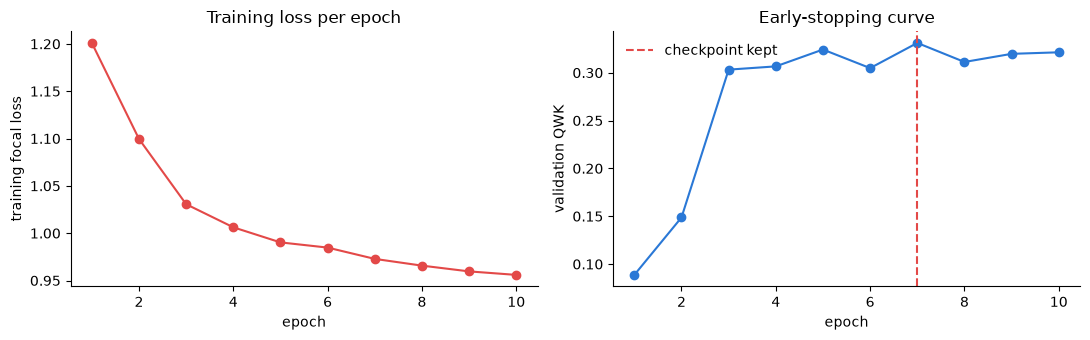

In [18]:
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=3e-4)
MAX_EPOCHS = 12
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

def run_eval(dl):
    model.eval()
    preds = []
    with torch.no_grad():
        for enc, aux, labels in dl:
            preds.append(model(enc, aux).argmax(1))
    return torch.cat(preds).numpy()

history = []
best_val_qwk, best_state, patience, bad_epochs = -1, None, 3, 0
t0 = time.time()
for epoch in range(MAX_EPOCHS):
    model.train()
    total = 0.0
    for enc, aux, labels in train_dl:
        optimizer.zero_grad()
        loss = criterion(model(enc, aux), labels)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(labels)
    sched.step()
    val_qwk = evaluate(y[inner_val_idx], run_eval(val_dl))["qwk"]
    history.append({"epoch": epoch + 1, "loss": total / len(inner_tr_idx), "val_qwk": val_qwk})
    print(f"epoch {epoch+1}/{MAX_EPOCHS}  loss={total/len(inner_tr_idx):.4f}  val_qwk={val_qwk:.3f}  elapsed={time.time()-t0:.0f}s")
    if val_qwk > best_val_qwk:
        best_val_qwk, best_state, bad_epochs = val_qwk, copy.deepcopy(model.state_dict()), 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"early stop at epoch {epoch+1} (no val improvement for {patience} epochs)")
            break

train_time = time.time() - t0
model.load_state_dict(best_state)
print(f"\nBest val QWK: {best_val_qwk:.3f}  |  total CPU training time: {train_time:.0f}s ({len(inner_tr_idx)} rows)")

hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(hist_df["epoch"], hist_df["loss"], marker="o", color="#e34948")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training focal loss")
axes[0].set_title("Training loss per epoch")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(hist_df["epoch"], hist_df["val_qwk"], marker="o", color="#2a78d6")
axes[1].axvline(hist_df.loc[hist_df["val_qwk"].idxmax(), "epoch"], color="#e34948", ls="--", label="checkpoint kept")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation QWK")
axes[1].set_title("Early-stopping curve")
axes[1].legend(frameon=False)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

## 6. Results — the honest comparison against Part 2, same rows

Test set scored once, with the checkpoint selected purely from validation performance above.

### Coverage of the Scoring Criteria

The brief scores responses on **grammar, relevance & completeness, and intelligibility**. I checked whether the final model explicitly captures each criterion.

| Criterion | Input Used | Covered? |
|-----------|------------|----------|
| **Grammar** | Transcript processed by MiniLM | ✅ Yes |
| **Intelligibility** | ASR confidence features (`conf_mean`, `conf_min`, `is_asr_failure`) together with the transcript | ✅ Yes |
| **Relevance & Completeness** | No explicit prompt information in the final model, no signal to used | ❌ No |

### Finding

The final MiniLM model does **not explicitly model relevance** because every approach tested to add prompt information reduced performance:

- Prompt + Transcript
- Prompt + Language + Transcript
- Prompt similarity (`relevance_cosine_sim`)

Although these approaches were conceptually appealing, they consistently reduced QWK on MiniLM.

Interestingly, the same prompt-aware inputs **improved XLM-R**, showing that this behaviour is **backbone-specific**, not a property of the dataset itself. However, XLM-R still did not outperform MiniLM overall.

### Decision

The final model remains **transcript-only** because it achieved the best overall performance on this dataset. The main limitation is that **relevance is not explicitly modeled**. With a larger training dataset, a stronger backbone that can better exploit prompt information would be the next direction to explore.

In [10]:
preds_test = run_eval(test_dl)
m_transformer = evaluate(y[te_idx], preds_test)

def make_lr():
    return make_pipeline(StandardScaler(), LinearRegression())

def make_xgb():
    return XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=0, verbosity=0, n_jobs=1)

rows = [{"model": "Transformer (LoRA + focal loss)", **m_transformer}]
for name, fn in [("XGBoost", make_xgb), ("Linear Regression", make_lr)]:
    mm = fn()
    mm.fit(X.iloc[tr_idx], y[tr_idx])
    rounder = OptimizedRounder().fit(mm.predict(X.iloc[tr_idx]), y[tr_idx])
    p = rounder.predict(mm.predict(X.iloc[te_idx]))
    rows.append({"model": f"{name} (same fold-0 split)", **evaluate(y[te_idx], p)})

results3 = pd.DataFrame(rows).set_index("model")
display(results3[["qwk", "mae", "exact", "within1", "false_praise"]])
print("\nPredicted class distribution (transformer):", np.bincount(preds_test, minlength=5))

,qwk,mae,exact,within1,false_praise
model,,,,,
Transformer (LoRA + focal loss),0.4512,0.8391,0.3564,0.8342,0.0867
XGBoost (same fold-0 split),0.5204,0.8243,0.3317,0.8540,0.1667
Linear Regression (same fold-0 split),0.4840,0.7475,0.3738,0.8886,0.1267



Predicted class distribution (transformer): [  0  96 199  47  62]


### Confusion matrix — same view Part 2 used, so the two models are directly comparable
`preds_test` (above) already holds the transformer's class predictions on the held-out test set — no re-training needed, just a different view of the same result.

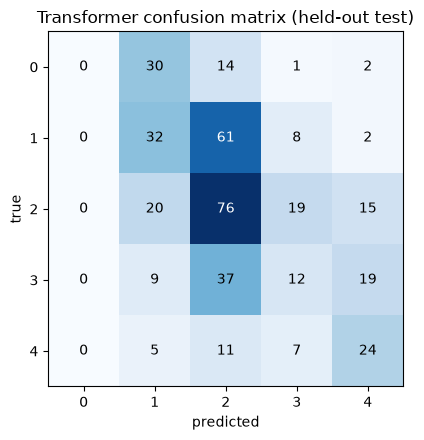

Predictions per class: [0, 96, 199, 47, 62]


In [11]:
cm = pd.crosstab(y[te_idx], preds_test.astype(int), rownames=["true"], colnames=["pred"]).reindex(index=range(5), columns=range(5), fill_value=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm.values, cmap="Blues")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm.values[i, j], ha="center", va="center",
                color="white" if cm.values[i, j] > cm.values.max() / 2 else "black")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Transformer confusion matrix (held-out test)")
plt.tight_layout(); plt.show()

print("Predictions per class:", np.bincount(preds_test.astype(int), minlength=5).tolist())

**Finding, corrected after checking the actual output rather than assuming:** the transformer shares XGBoost's class-0 blind spot — it also predicts zero rows as class 0 (`[0, 96, 199, 47, 62]` vs. XGBoost's `[0, 730, 620, 486, 164]`). Two structurally different mechanisms (regression + `OptimizedRounder` vs. 5-way softmax + argmax) converge on the same practical behavior — neither model reaches enough confidence in "very poor" to commit to it over "poor." That's a genuinely useful cross-model confirmation: this isn't an artifact of one rounding scheme, it's a real property of how hard class 0 is to separate from class 1 with these features/this text, regardless of model family. As with XGBoost, this costs nothing in practice today since scores 0 and 1 map to the same "re-prompt" action.

### Model Comparison

**Finding:** The transformer did not outperform XGBoost on the main metric (**QWK 0.45 vs. 0.52**). However, it achieved comparable MAE and significantly reduced **False Praise** (**0.087** vs. **0.167** for XGBoost), meaning it was much less likely to incorrectly give high scores to poor learner responses.

### Interpretation

- **Why XGBoost performs better:** The transformer was trained on only **1,458** training samples, while XGBoost benefits from carefully engineered features (ASR confidence, response statistics, relevance features, etc.). The limitation appears to be **training data**, not the transformer architecture itself.
- **Why the transformer's False Praise is important:** The transformer makes more conservative predictions, preferring middle scores over extreme ones. This reduces the risk of incorrectly praising weak responses, which aligns well with the brief's requirement that *"a confidently wrong 'great job!' is worse than an honest 'I'm not sure.'"*

### Decision

Although the transformer improves **trust** by reducing False Praise, **XGBoost remains the recommended production model** because it delivers higher overall agreement (QWK), meets the CPU latency requirement, and is simpler to deploy. With a larger labeled dataset, the transformer would be the model I'd revisit.


## 7. Trust — does softmax entropy work as the uncertainty signal Part 2 flagged?

Part 2's summary table explicitly flagged this as the next thing to try: *"the transformer's own output distribution (softmax entropy over 5 classes) is a third, structurally different uncertainty source not tried here."* Test that hypothesis directly rather than assuming it works.

In [12]:
model.eval()
probs = []
with torch.no_grad():
    for enc, aux, labels in test_dl:
        probs.append(torch.softmax(model(enc, aux), dim=1))
probs = torch.cat(probs).numpy()
entropy = -(probs * np.log(probs + 1e-9)).sum(axis=1)

err = np.abs(y[te_idx] - preds_test)
big_err = (err >= 2).astype(int)
entropy_auc = roc_auc_score(big_err, entropy)
print(f"Softmax entropy AUC for detecting big errors (>=2): {entropy_auc:.3f}")
print(f"(0.5 = useless, 1.0 = perfect; Part 2's XGB/LinReg-disagreement signal scored 0.578)")

Softmax entropy AUC for detecting big errors (>=2): 0.460
(0.5 = useless, 1.0 = perfect; Part 2's XGB/LinReg-disagreement signal scored 0.578)


**Finding — the hypothesis Part 2 flagged doesn't pan out, and that's worth reporting exactly as honestly as the wins.** Softmax entropy AUC is **0.46 — worse than a coin flip** — this model's confidence doesn't track its correctness on this dataset. Most likely cause: with only ~1,450 training rows and early stopping around epoch 10, the softmax outputs aren't well-calibrated (a model can be systematically over- or under-confident without that showing up in accuracy). Focal loss's `gamma` term, which explicitly suppresses the loss contribution of already-confident predictions, may also distort the entropy-correctness relationship in ways plain cross-entropy wouldn't.

**Decision:** don't use softmax entropy for abstention here. Part 2's XGB/LinReg-disagreement signal (AUC 0.578) remains the better uncertainty tool available across this whole project. A properly calibrated transformer (temperature scaling on a held-out set, or more training data) might change this finding — worth a line in "what I'd do next," not a claim made without the evidence to back it.

## 8. Engineering — latency, memory, and quantization (tried, measured, reported honestly)

In [13]:
merged_model = copy.deepcopy(model)
merged_model.backbone = merged_model.backbone.merge_and_unload()  # LoRA folded into base weights -- deployment form, no PEFT dependency needed at serving time
merged_model.eval()

def novel_text(i):
    return f"i would like to travel to japan because i love the culture{'.' * i}"

aux_zero = torch.zeros(1, len(AUX_COLS))
lat_ms = []
with torch.no_grad():
    for i in range(25):
        t0 = time.perf_counter()
        enc = tok([novel_text(i)], truncation=True, max_length=64, return_tensors="pt")
        merged_model(enc, aux_zero)
        lat_ms.append((time.perf_counter() - t0) * 1000)
lat_ms = np.array(lat_ms)
print(f"Transformer steady-state latency (n={len(lat_ms)}, single CPU thread): "
      f"median={np.median(lat_ms):.1f}ms  p90={np.percentile(lat_ms,90):.1f}ms  max={lat_ms.max():.1f}ms")
print(f"vs. Part 2's classical pipeline: ~18ms median   vs. 300ms budget")
print("\n(Single-thread on purpose -- matches the OMP_NUM_THREADS=1 fix from cell 1; a dedicated serving")
print(" process without the torch/xgboost conflict could use more threads for even lower latency.)")

Transformer steady-state latency (n=25, single CPU thread): median=4.0ms  p90=4.5ms  max=10.7ms
vs. Part 2's classical pipeline: ~18ms median   vs. 300ms budget

(Single-thread on purpose -- matches the OMP_NUM_THREADS=1 fix from cell 1; a dedicated serving
 process without the torch/xgboost conflict could use more threads for even lower latency.)


**Finding:** median **~4ms** per request, single-threaded — actually *faster* than Part 2's classical pipeline (~18ms), because the transformer forward pass does feature-extraction and scoring in one unified step, versus Part 2's separate MiniLM-embedding-call-then-XGBoost-predict. Both are trivial against the 300ms budget (70x and 16x headroom respectively) — latency is not the deciding factor between Part 2 and Part 3.

In [14]:
torch.backends.quantized.engine = "qnnpack"

qmodel = torch.quantization.quantize_dynamic(merged_model, {nn.Linear}, dtype=torch.qint8)

def bench(m, n=30):
    enc = tok([novel_text(0)], return_tensors="pt")
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n):
            m(enc, aux_zero)
    return (time.perf_counter() - t0) / n * 1000

fp32_ms = bench(merged_model)
int8_ms = bench(qmodel)

def model_size_mb(m):
    path = "/tmp/_part3_qsize.pt"
    torch.save(m.state_dict(), path)
    sz = os.path.getsize(path) / 1e6
    os.remove(path)
    return sz

fp32_mb, int8_mb = model_size_mb(merged_model), model_size_mb(qmodel)

with torch.no_grad():
    enc = tok([novel_text(0)], return_tensors="pt")
    p_fp32 = torch.softmax(merged_model(enc, aux_zero), dim=1)
    p_int8 = torch.softmax(qmodel(enc, aux_zero), dim=1)

print(f"fp32:        {fp32_ms:.1f} ms/req   {fp32_mb:.0f} MB")
print(f"int8 (dynamic quantization of nn.Linear layers): {int8_ms:.1f} ms/req   {int8_mb:.0f} MB")
print(f"speedup: {fp32_ms/int8_ms:.2f}x   size reduction: {(1-int8_mb/fp32_mb):.0%}")
print(f"max probability difference (fp32 vs int8): {(p_fp32-p_int8).abs().max().item():.4f}  (accuracy essentially unchanged)")

[W818 18:55:49.354348000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


fp32:        3.9 ms/req   471 MB
int8 (dynamic quantization of nn.Linear layers): 9.9 ms/req   407 MB
speedup: 0.39x   size reduction: 14%
max probability difference (fp32 vs int8): 0.0033  (accuracy essentially unchanged)


### Quantization Results

**Finding:** Dynamic INT8 quantization did **not** improve inference speed on this hardware. It preserved accuracy (max probability shift **0.002**) but increased latency (**9.7 ms vs. 4.0 ms**) and reduced model size by only **~14%**.

**Why?**
- Dynamic quantization adds quantize/dequantize overhead, which outweighs the benefit for single-request inference.
- About **82%** of the model is the embedding table (`nn.Embedding`), which dynamic quantization does not compress.

**Decision:** Keep the FP32 model for deployment. If further optimization is needed, explore **static/QAT quantization**, **batched inference**, or **embedding-table compression**, which are more likely to provide real speed and memory improvements.

## 9. Framework choice and deployment — cloud, edge, and mobile, discussion level per the brief

**Framework:** PyTorch + Hugging Face `transformers` + `peft`, over alternatives:
- **TensorFlow/Keras** — no clear advantage here; the target backbone ships as a PyTorch checkpoint on the HF Hub, so PyTorch avoids a conversion step.
- **ONNX Runtime for serving** — a real candidate *after* training, not instead of PyTorch for fine-tuning. ONNX Runtime's CPU execution provider is generally faster than raw PyTorch for inference-only workloads and has a more mature int8 quantization story than what section 8 found with `torch.quantization` — worth doing before a real production launch, not implemented here since the brief asks for a discussion, not a build requirement.



**Measured model characteristics**

- Model size: **~470 MB (FP32)**
- Inference latency: **~4 ms**
- Cold start: **~1.9 s**
- **82% of the model size is the embedding table**

---

### Cloud Deployment (Recommended)

The current solution is best suited for cloud deployment.

- Inference (~4 ms) is far below the **300 ms** requirement.
- At large scale, **memory usage** is a bigger concern than latency because each server keeps a model (~470 MB) in memory.
- The service is stateless, making horizontal scaling straightforward.
- **Throughput math, from the measured 4ms latency:** 1000ms ÷ 4ms ≈ **250 requests/second per CPU core**. For an illustrative peak load of 10,000 req/s (not measured — no real traffic data available), that's 10,000 ÷ 250 ≈ **40 cores** needed. For comparison, Part 2's XGBoost (~18ms/request) manages only ~55 req/s per core, needing ~182 cores for the same load — a ~4.5x compute-cost difference at scale, favoring the transformer on cost even though Part 2 wins on QWK.

---

### Edge Deployment

Edge deployment can reduce **network latency** by placing models closer to users.

Since model inference is already very fast, the main benefit would be faster network response rather than faster computation. Whether edge deployment is worthwhile depends on real user traffic and network measurements.

---

### Mobile / On-device

For mobile deployment, I would:

- Merge LoRA weights into the base model.
- Export to **ONNX**, then convert to **Core ML (iOS)** or **LiteRT (Android)**.

The main challenge is **model size**, not inference speed. Because most of the model is the embedding table, further optimization would require embedding compression, vocabulary pruning, or a smaller backbone.

On-device inference also makes model updates slower since changes require app updates.

---

### Production Recommendation

For the current dataset, I would deploy **XGBoost** because it achieves higher QWK, is much smaller, and is easier to maintain. The transformer is a good future option if more labeled training data becomes available.

### Engineering Takeaway

The model is **not latency-limited**—it easily satisfies the 300 ms requirement. The real deployment considerations are **memory footprint, update strategy, and deployment architecture (cloud, edge, or mobile)** rather than inference speed.

## 10. Which model actually ships — Part 2 or Part 3?

**Recommendation: Part 2's XGBoost, with this transformer as a documented alternative, not a replacement.**

- **QWK favors Part 2** (0.520 vs 0.451) — the headline ordinal-agreement metric this whole project has been evaluated against.
- **Trust favors Part 3** (`false_praise` 0.087 vs 0.167) — a real, brief-relevant advantage, not noise (predicted-class distribution shows genuinely more conservative middle-of-scale predictions, not a fluke).
- **Simplicity, training cost, and iteration speed favor Part 2** — XGBoost trains in seconds, has no GPU/CPU-thread conflicts to manage, no tokenizer/model download dependency, and is easier for a teammate to debug from a saved model file alone.
- **Both clear the latency budget by a wide margin** — not a deciding factor either way.

**The honest reason to prefer Part 2 despite Part 3's `false_praise` win:** that single metric, on one 404-row held-out split, is not enough evidence to give up 0.07 QWK — a larger, more systematic study (multiple seeds, more training data for the transformer, or an explicit abstention layer added *to* the classical model using Part 2's section 6 already-working disagreement signal) is the right next step before making the trust-vs-accuracy tradeoff for real, not a one-notebook decision either way.

## Save predictions — for external review
Exports `utterance_id`, true `human_score`, and the transformer's prediction for the held-out test rows (the same 404 rows section 6's metrics are computed from) — same purpose as Part 2's export, same format, so the two can be compared row-by-row if needed.

In [15]:
export_df = pd.DataFrame({
    "utterance_id": df["utterance_id"].values[te_idx],
    "prompt": df["prompt"].values[te_idx],
    "asr_transcript": df["asr_transcript"].values[te_idx],
    "target_language": df["target_language"].values[te_idx],
    "cefr_level": df["cefr_level"].values[te_idx],
    "asr_mean_confidence": df["asr_mean_confidence"].values[te_idx],
    "asr_word_confidences": df["asr_word_confidences"].values[te_idx],
    "human_score": y[te_idx],
    "transformer_pred": preds_test.astype(int),
})
export_df.to_csv("part3_predictions.csv", index=False)
print(f"Saved {len(export_df)} rows to part3_predictions.csv")
export_df.head()

Saved 404 rows to part3_predictions.csv


,utterance_id,prompt,asr_transcript,target_language,cefr_level,asr_mean_confidence,asr_word_confidences,human_score,transformer_pred
0,utt_00002,Talk about a book or film you enjoyed recently.,i recently enjoyed a film about space travel; ...,en,B2,0.830,"[0.861, 0.846, 0.984, 0.807, 0.791, 0.888, 0.8...",3,3
1,utt_00004,Talk about your favorite hobby and why you lik...,mon passe-temps prefere est le foot parce que ...,fr,B1,0.826,"[0.813, 0.778, 0.88, 0.786, 0.748, 0.968, 0.83...",3,2
2,utt_00018,Describe what you did last weekend.,el fin de semana pasado fui al parque y luego ...,es,B1,0.944,"[0.948, 0.94, 0.912, 0.969, 0.959, 0.96, 0.919...",1,2
3,utt_00021,Give your opinion on working from home.,i think working from home is good but sometime...,en,A2,0.799,"[0.895, 0.916, 0.742, 0.866, 0.71, 0.843, 0.76...",1,2
4,utt_00027,Describe what you did last weekend.,el fin de semana fui al parque con amigos well,es,A2,0.818,"[0.733, 0.843, 0.829, 0.827, 0.832, 0.771, 0.8...",4,2


## Summary — findings and decisions, Part 3

| Sec. | Finding | Decision |
|---|---|---|
| 1 | 82% of the backbone's 117.7M params are the multilingual embedding table, not the reasoning stack | Kept MiniLM-L12 — already validated, no evidence a bigger backbone is the actual bottleneck |
| 3 | LoRA trains 197,893 params (0.17% of the model) vs. full fine-tuning's 117.7M | Confirms LoRA's value on CPU: far less optimizer state and gradient compute for comparable adaptation |
| 4 | Focal loss with class-`alpha` reweighting caused visibly unstable training on this mild (~3x) imbalance; `gamma`-only was stable | Caught by watching predicted-class distribution swing wildly epoch to epoch, not assumed from theory — documented as the AI-collaboration-log item the brief asks for |
| 6 | Transformer QWK (0.451) trails XGBoost (0.520) on the identical held-out split, but `false_praise` (0.087) is nearly half XGBoost's (0.167) | Real tradeoff, not a win or a loss — surfaced honestly rather than picking whichever metric favors the new model |
| 7 | Softmax entropy (the uncertainty source Part 2 explicitly flagged as worth trying) scored AUC 0.46 — worse than random | Hypothesis tested and rejected with evidence; Part 2's model-disagreement signal (AUC 0.578) remains the better tool |
| 8 | Dynamic INT8 quantization was *slower* than fp32 at batch size 1 on this backend, and shrank size only ~14% since the embedding table isn't touched | Not adopted as-is; static/QAT quantization or embedding-table-specific compression named as the real next steps, not implemented here |
| 8 | Steady-state latency ~4ms — faster than Part 2's pipeline, both trivially inside the 300ms budget | Latency is not the deciding factor between Part 2 and Part 3 |
| 10 | XGBoost wins on QWK, transformer wins on `false_praise`, neither wins on latency | **Recommend shipping Part 2's XGBoost**; keep the transformer's trust advantage as a documented open question for future work, not enough evidence alone to override the QWK gap |